# Capítulo 2 – Proyecto de Machine Learning de Extremo a Extremo



En este cuaderno vamos a desarrollar de forma práctica el contenido del **Capítulo 2** del libro *Aprende Machine Learning con Scikit-Learn, Keras y TensorFlow* (3.ª edición) de Aurélien Géron.

En este capítulo, el enfoque central es abordar un **proyecto de Machine Learning completo**, siguiendo una secuencia lógica y profesional:

1. **Enmarcar el problema**: comprender el objetivo del proyecto, definir si se trata de clasificación o regresión, seleccionar métricas de desempeño, etc.  
2. **Recolectar y preparar los datos**: en este caso, utilizaremos el conjunto de datos de los precios de viviendas en California, originalmente del censo de 1990. Se realizarán transformaciones, se integrará un atributo categórico y se eliminarán variables innecesarias, con el fin de adecuar los datos al propósito de aprendizaje :contentReference[oaicite:7]{index=7}.  
3. **Entrenar y evaluar un modelo**: se implementará un `DecisionTreeRegressor` usando Scikit-Learn, y se explorará cómo regularizarlo y visualizar su estructura, entendiendo tanto su potencial como sus limitaciones.  
4. **Pipeline completo**: construiremos un flujo de trabajo reproducible que incluya todas las etapas del proyecto, desde la carga de datos hasta la evaluación final del modelo, reflejando el flujo recomendado en el capítulo.

Este notebook está diseñado para ser accesible y formativo, ya sea para docentes como tú, estudiantes o profesionales que deseen adentrarse en un proceso realista y completo de Machine Learning. Se complementa con explicaciones teóricas esenciales, fragmentos de código comentados y visualizaciones claras.

¡Comencemos esta exploración práctica!

## Librerias

In [45]:
from pathlib import Path
import pandas as pd   # Corregido
import tarfile
import urllib.request  # Corregido
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
#
from zlib import crc32
#
from sklearn.model_selection import train_test_split
#
from sklearn.model_selection import StratifiedShuffleSplit
#genera una visualizacion grafica de correlacion
from pandas.plotting import scatter_matrix
#
from sklearn.impute import SimpleImputer
#
from sklearn.preprocessing import OneHotEncoder
#
from sklearn.preprocessing import MinMaxScaler
#
from sklearn.preprocessing import StandardScaler
#

## Cargar el archivo

In [7]:
def load_housing_data():
    tarball_path=Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url= "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url,tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

In [8]:
housing=load_housing_data()

## Exploracion de datos

In [9]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [10]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [11]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [12]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


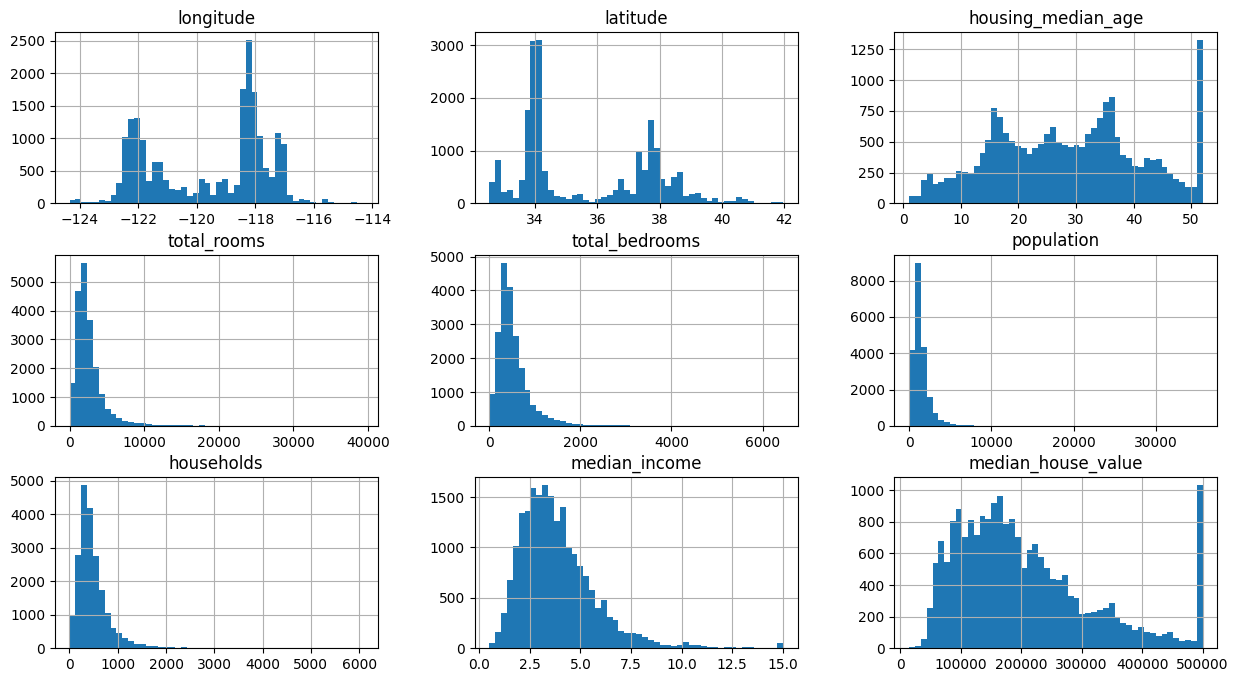

In [19]:
housing.hist(bins=50, figsize=(15,8))
plt.show()



1. **Edad mediana de la casa (`housing_median_age`)**

   * En los histogramas, se observa que muchas casas tienen exactamente **50 años**.
   * Esto no significa que todas esas casas tengan justo esa edad, sino que el dataset tiene un **límite superior (censura)**: cualquier casa con más de 50 años fue codificada como "50".
   * Por lo tanto, este valor no es exacto más allá de ese punto.
   * El libro te advierte que esto puede ser un problema, ya que el modelo no podrá distinguir entre una casa de 51 y otra de 100 años: ambas aparecen como "50".

2. **Valor medio de la vivienda (`median_house_value`)**

   * También existe un límite: ningún valor supera los **500.000 dólares**.
   * De nuevo, esto significa que los precios de las casas más caras fueron **truncados o recortados**.
   * Esto puede ser un problema si en la práctica necesitas predecir precios más altos, porque el modelo no ha visto ejemplos reales por encima de ese límite.


3. **Opciones que menciona el libro**
   Ante este problema de datos censurados, sugiere varias estrategias:

   * **Hablar con el equipo cliente (si fuera un proyecto real)** para confirmar si esos límites afectan al objetivo del modelo.
   * **Recolectar más datos** que incluyan precios más altos y edades de casas más grandes, si es posible.
   * **Eliminar distritos censurados**: en algunos casos puedes optar por quitar del dataset los ejemplos con valores en los topes (casas con `age=50` o `value=500000`).
   * **Aceptar los límites y continuar**: si no es crítico para tu problema, puedes entrenar igualmente el modelo, entendiendo sus limitaciones.


4. **Nota sobre escalas diferentes**
   Al final, menciona que los atributos (ejemplo: `median_income` con valores de 0 a 15, frente a `population` con valores de 0 a 30.000) están en **escalas muy distintas**.

   * Eso no es un problema inmediato para todos los modelos, pero sí lo será para algoritmos sensibles a la escala (ej. regresión lineal, SVM, redes neuronales).
   * Por eso más adelante se introduce el **escalado de características** (normalización o estandarización) para equilibrar los atributos.

**En resumen:**
El texto te está alertando que el dataset **no es perfecto**:

* Tiene variables con valores **censurados** (edad de casa y precio de vivienda).
* Esto limita la capacidad del modelo para generalizar más allá de esos topes.
* Tú, como analista, debes decidir si recolectar más datos, eliminar los ejemplos truncados o simplemente aceptar esa limitación.
* Además, recuerda que más adelante deberás **escalar** los datos para que las distintas variables sean comparables.


1. **Distribución sesgada (asimetría a la derecha)**

   * La mayoría de los atributos numéricos como `total_rooms`, `total_bedrooms`, `population` y `households` presentan distribuciones fuertemente sesgadas hacia la izquierda (muchos valores pequeños y pocos valores extremadamente grandes).
   * Esto indica la existencia de **outliers** que podrían afectar negativamente a algunos modelos sensibles a la escala o la dispersión (ej. regresión lineal).

2. **Presencia clara de outliers**

   * Variables como `total_rooms`, `population` y `median_house_value` muestran colas largas con valores extremos.
   * Será necesario revisar estos casos y considerar técnicas como **winsorización**, **transformaciones logarítmicas** o bien **detección y tratamiento de outliers**.

3. **Atributos con límites marcados**

   * En `housing_median_age`, se observa un corte abrupto en el valor 50. Esto sugiere que el dataset fue **censurado o truncado** en ese valor máximo.
   * En `median_house_value` también hay un límite en 500,000, indicando un **tope artificial en los precios de vivienda**. Esto es importante, porque puede sesgar modelos de predicción y requiere estrategias para manejar datos censurados.

4. **Atributos con distribuciones más “naturales”**

   * `median_income` tiene una distribución más cercana a la normal, aunque sigue siendo ligeramente asimétrica. Este atributo es fundamental, ya que suele ser el predictor más fuerte en este dataset.

5. **Acciones recomendadas para el preprocesamiento**

   * Aplicar **transformaciones logarítmicas** en variables con colas largas (`total_rooms`, `population`, `households`).
   * Considerar **normalización o estandarización** para modelos que lo requieran.
   * Evaluar técnicas de **ingeniería de atributos** (por ejemplo, `rooms_per_household`, `bedrooms_per_room`, `population_per_household`) que suelen mejorar el rendimiento en este dataset.
   * Tratar con especial cuidado las variables censuradas (`housing_median_age`, `median_house_value`).



## Crear un conjunto de prueba

Para no caer en el sesgo del "espionaje de datos" nuestra percepcion es propensa al sobrejauste: el conjunto de prueba, puede que te topes con algun patron aprentemente interesante en los datos de prueba que te lleva a seleccionar un tipo particular de modelo de mchine learning. 

Crear un conjunto de prueba es simple: elige alugnas instancias de forma aleatoria, por lo general el 20% del conjunto de datos y se deben dejar aparte. 

### Muestreo estratificado

1. **El problema del muestreo aleatorio simple**

   * Si eliges ejemplos al azar, puede que el conjunto de entrenamiento y el de prueba **no reflejen bien la distribución real** de los datos.
   * Ejemplo: En una encuesta política, si preguntas al azar a 1.000 personas, puedes terminar con proporciones distintas de mujeres y hombres que las que hay en la población real.

2. **El concepto de muestreo estratificado**

   * En lugar de tomar muestras completamente al azar, divides la población en **estratos** (grupos que comparten una característica importante, como sexo, edad, ingresos, etc.).
   * Luego, seleccionas aleatoriamente dentro de cada estrato en proporciones similares a las de la población.
   * Esto asegura que los conjuntos de entrenamiento y prueba **mantengan las mismas proporciones de los grupos clave** que hay en la población real.

3. **Aplicación en el dataset de California Housing**

   * Los expertos creen que el **ingreso medio** (`median_income`) es una variable muy importante para predecir los precios de vivienda.
   * Entonces, conviene hacer el muestreo estratificado en base a esa variable:

     * Se crea una nueva columna con **categorías de ingreso** (ejemplo: de 0–1.5, 1.5–3, 3–4.5, etc.).
     * Luego, se divide el dataset en entrenamiento y prueba respetando esas proporciones.
   * De esta forma, tanto el conjunto de entrenamiento como el de prueba tendrán representados los distintos niveles de ingreso de manera equilibrada.

- En resumen:

El texto quiere decirte que **no basta con dividir tus datos al azar**:

* Si no tienes cuidado, los conjuntos de entrenamiento y prueba podrían estar **desequilibrados** y no reflejar bien la población real.
* Para evitarlo, se recomienda usar **muestreo estratificado**, asegurándote de que los conjuntos mantengan las proporciones correctas de variables clave (en este caso, los ingresos).



#### Muestreo estratificado basado en la categoria de ingresos

In [21]:
housing["income_cat"] = pd.cut(housing["median_income"],
                            bins    = [0., 1.5, 3.0, 4.5, 6., np.inf],
                            labels  = [1,2,3,4,5]
                        )

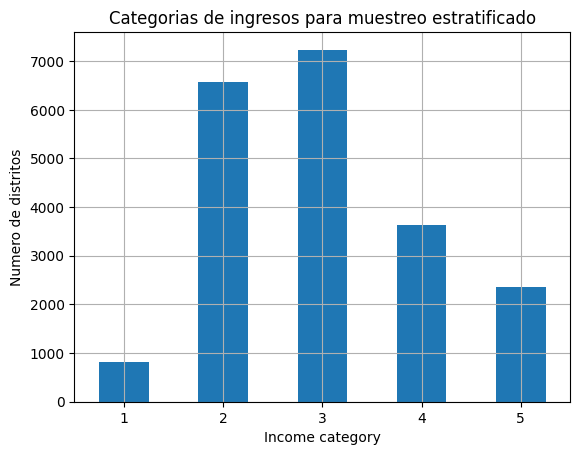

In [27]:
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0,grid=True)
plt.xlabel("Income category")
plt.ylabel("Numero de distritos")
plt.title("Categorias de ingresos para muestreo estratificado")
plt.show()

In [28]:
splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []
for train_index, test_index in splitter.split(housing,housing["income_cat"]):
    strat_train_set_n = housing.iloc[train_index]
    strat_test_set_n  = housing.iloc[test_index]
    strat_splits.append([strat_train_set_n,strat_test_set_n]) 

In [29]:
strat_train_set, strat_test_set = strat_splits[0]

hay una manera mas breve de conseguir una sola divsion usando la funcion `train_test_split()` co nel argumento `stratify`:

In [30]:
strat_train_set, strat_test_set = train_test_split(
    housing, test_size = 0.2, stratify=housing["income_cat"], random_state=42
)

fijarse en las proporaciones de la categoria de ingresos en el conjunto de pruebas: 

In [31]:
strat_test_set["income_cat"].value_counts()/len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [32]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

## Exploracion y visualizacion de los datos

In [33]:
housing = strat_train_set.copy()

### Visualizar datos geograficos

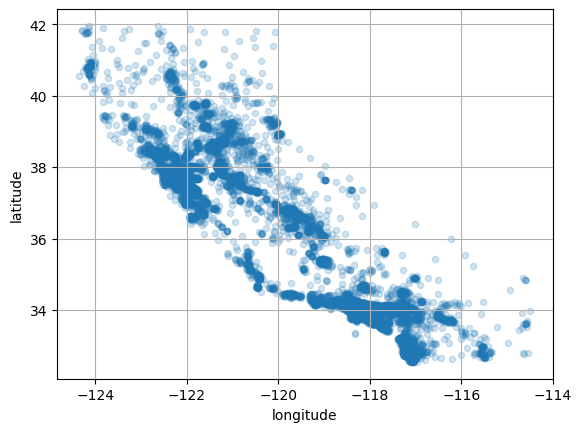

In [36]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2) #Agregar alpha=0.2 nos permite visualizar la densidad 
plt.show()

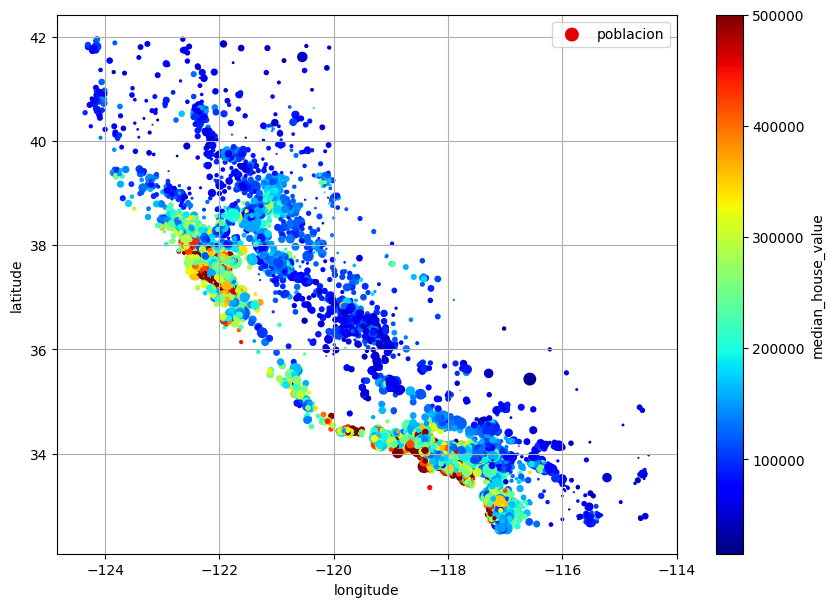

In [39]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s = housing["population"]/100, label = "poblacion",
             c = "median_house_value", cmap="jet", colorbar=True, 
             legend=True, sharex=False, figsize=(10,7)
             )
plt.show()

### Buscar correlaciones

In [44]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

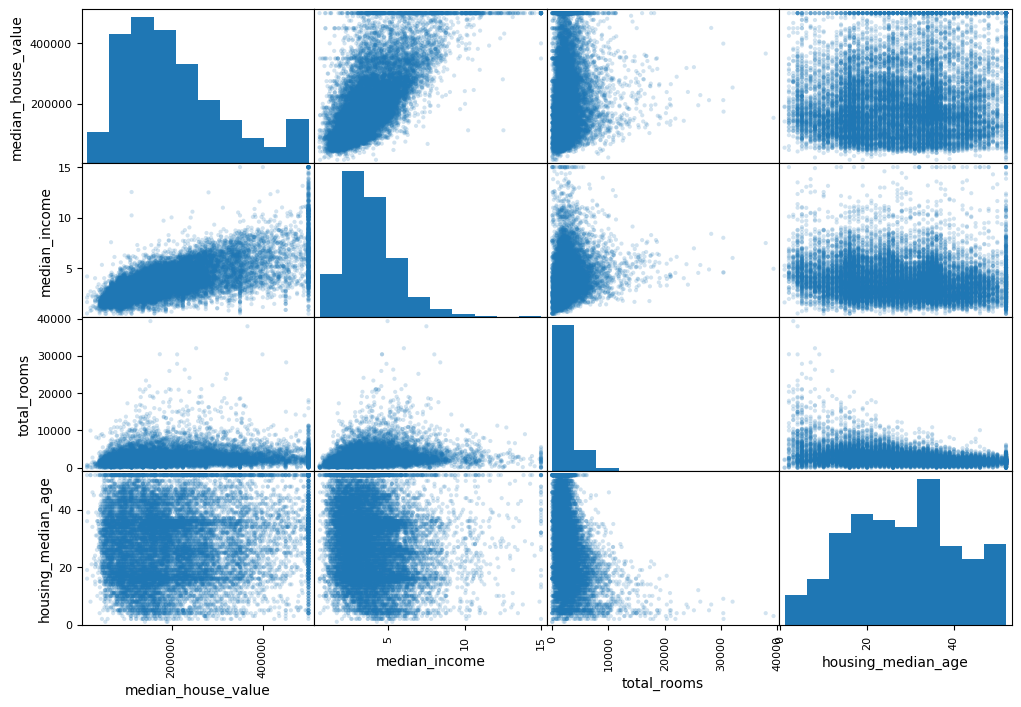

In [47]:
attributes = ["median_house_value","median_income","total_rooms","housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12,8),alpha=0.2)
plt.show()

A partir de este mapa y los valores de correlacion de un 0.69 el atributo mas prometedor para predecir el valor mediano de las casas es el de los ingresos medianos.  

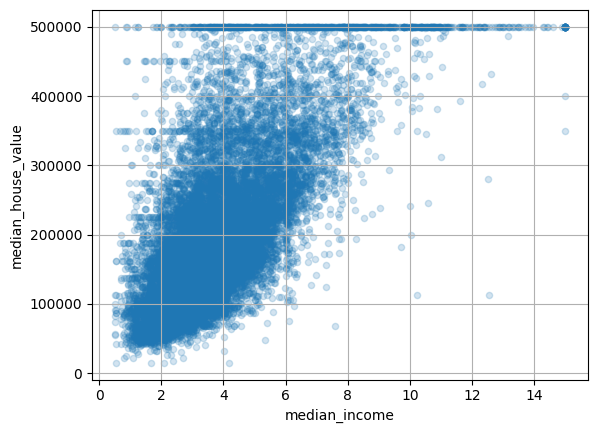

In [48]:
housing.plot(kind="scatter",x="median_income", y="median_house_value", alpha=0.2, grid=True)
plt.show()